In [2]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import scipy as cp
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/sdtools"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/Users/lloyd/Documents/hermes_dir/analysis/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *

# from code_comparison.code_comparison import *
from code_comparison.solps_pp import *
from code_comparison.solps_variables import *
# from code_comparison.viewer_2d import *

# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


# SOLPS I/O

In [3]:
case = SOLPScase('/Users/lloyd/Documents/hermes_dir/york-step_analysis_intro/data/solps')


## Printing available variables, sadly no metadata for these from what I can find

In [4]:

params_sorted = sorted(case.params)
n_cols = 3
params_array = np.array_split(params_sorted, n_cols)

for row in zip(*params_array):
    print(f"{row[0]:<30} {row[1]:<30} {row[2] if len(row) > 2 else '':<30}")

Bpol                           fhey_cond                      fnax_C+6_nanom                
Btor                           fhey_dia                       fnax_C+6_panom                
Btot                           fhey_ecrb                      fnax_C+6_pinch                
M                              fhey_pschused                  fnax_C+6_pll                  
NVd+                           fhey_strange                   fnax_C+6_pschused             
Na                             fhey_thermj                    fnax_C+6_tot                  
Ne                             fhey_total                     fnax_C+6_vsprcur              
Nm                             fhi_32                         fnax_C0_ch                    
Nn                             fhi_52                         fnax_C0_drift                 
Pa                             fhi_anml                       fnax_C0_drift_50              
Pd+                            fhi_cond                       fnax_C0_

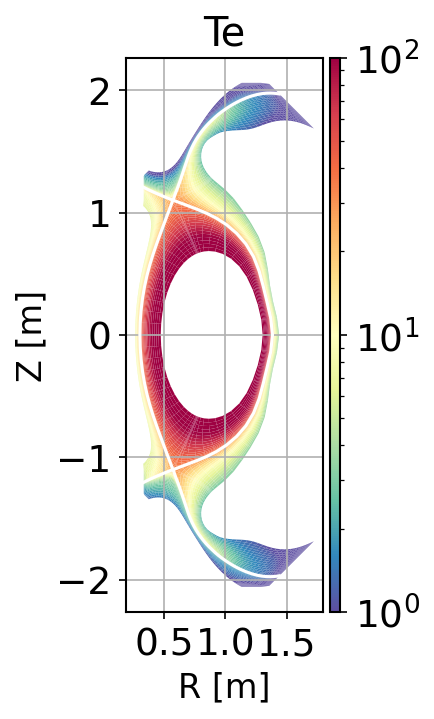

In [5]:
# %matplotlib widget

vmin = 1
vmax = 100
case.plot_2d("Te", logscale=True, cbar=True, vmin=vmin, vmax=vmax)

# 1D radial profiles (maybe build up a 2D picture?) to determine input sources for Hermes-3 1D

# Inputs required

## Geometry
- Connection length (to target and x-point)
    - xpoint = np.min(Btot)
- Flux expansion
    - From SOLPS Btot/Btot_xpoint
- Flux tube mapping
    - Derive Lambda_int from SOLPS heat flux width, lambda_int = lambda_q + 1.64*S, where S is the divertor broadening (wtf is this?)
        - S is turbulence broadening, which we can find from SOLPS from analsyis of Lambda_q at the OMP and Lambda_int at the target


## Sources
- Input power
- Input particles
- Parallel source distribution

## Impurity fraction
- Fixed fraction vs ful impurity transport (could trial it for Hermes-3 here)



# Field line geometry component inputs

## Connection length

In [6]:
fline = case.get_1d_poloidal_data(
    params = ["R", "Z", "Btot"],
    region = "outer_lower",
    sepadd = 0,
    target_first = False,
    guards = False
)

print('Connection length =' ,fline['Spar'].iloc[-1], 'm')


Connection length = 27.520701887675383 m


## Flux expansion (this is calculated in field line geometry, just need to provide B fields)

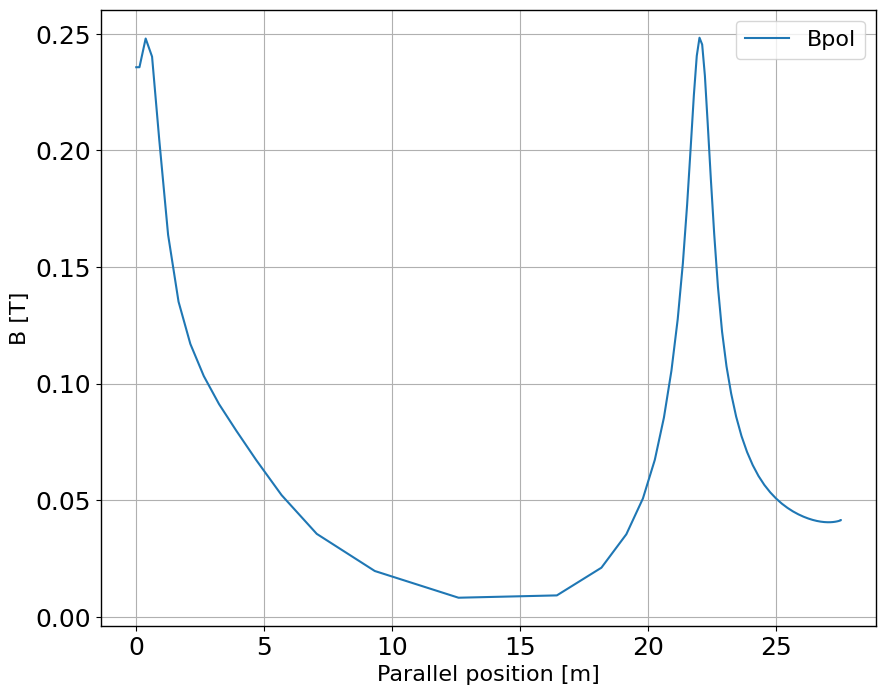

In [7]:
fline = case.get_1d_poloidal_data(
    params = ["R", "Z", "Btot", "Bpol", "Btor"],
    region = "outer_lower",
    sepadd = 0,
    target_first = False,
    guards = False
)



fig,ax = plt.subplots(figsize=(10,8))
# ax.plot(fline['Spar'], fline['Btot']/fline['Bpol'])
# ax.plot(fline['Spar'], fline['Btot'], label = 'Btot')
ax.plot(fline['Spar'], fline['Bpol'], label = 'Bpol')
# ax.plot(fline['Spar'], fline['Btor'], label = 'Btor')
ax.set_xlabel("Parallel position [m]")
ax.set_ylabel("B [T]")
ax.legend()
# ax.grid(True, alpha=0.3)


Downsampling from 67 to ~15 points using 'uniform' method
Using 15 points for fitting

BOUT++ INPUT FILE FORMAT - Polynomial Fit for Bpol

# Original data points: 67
# Downsampled to: 15 points (uniform method)
# Polynomial degree: 10
# Spline R² (on original data): 0.647141, RMSE: 4.353506e-02
# Polynomial R² (on original data): 0.795486, RMSE: 3.314368e-02
# Spar range: [0.000000, 27.520702]
# Variable is normalized: y_norm = (Spar - 0.000000) / 27.520702

# Coefficients
coef0 = -1.47365109e+04
coef1 = 7.24241149e+04
coef2 = -1.51006100e+05
coef3 = 1.74102325e+05
coef4 = -1.21279026e+05
coef5 = 5.23547553e+04
coef6 = -1.37955684e+04
coef7 = 2.08896790e+03
coef8 = -1.55967161e+02
coef9 = 2.81511028e+00
coef10 = 2.35368845e-01

# Polynomial expression
Bpol = y^10*coef0 + y^9*coef1 + y^8*coef2 + y^7*coef3 + y^6*coef4 + y^5*coef5 + y^4*coef6 + y^3*coef7 + y^2*coef8 + y^1*coef9 + coef10

# Where y is the normalized coordinate:
# y = (Spar - 0.000000) / 27.520702

# To enforce non-negativi

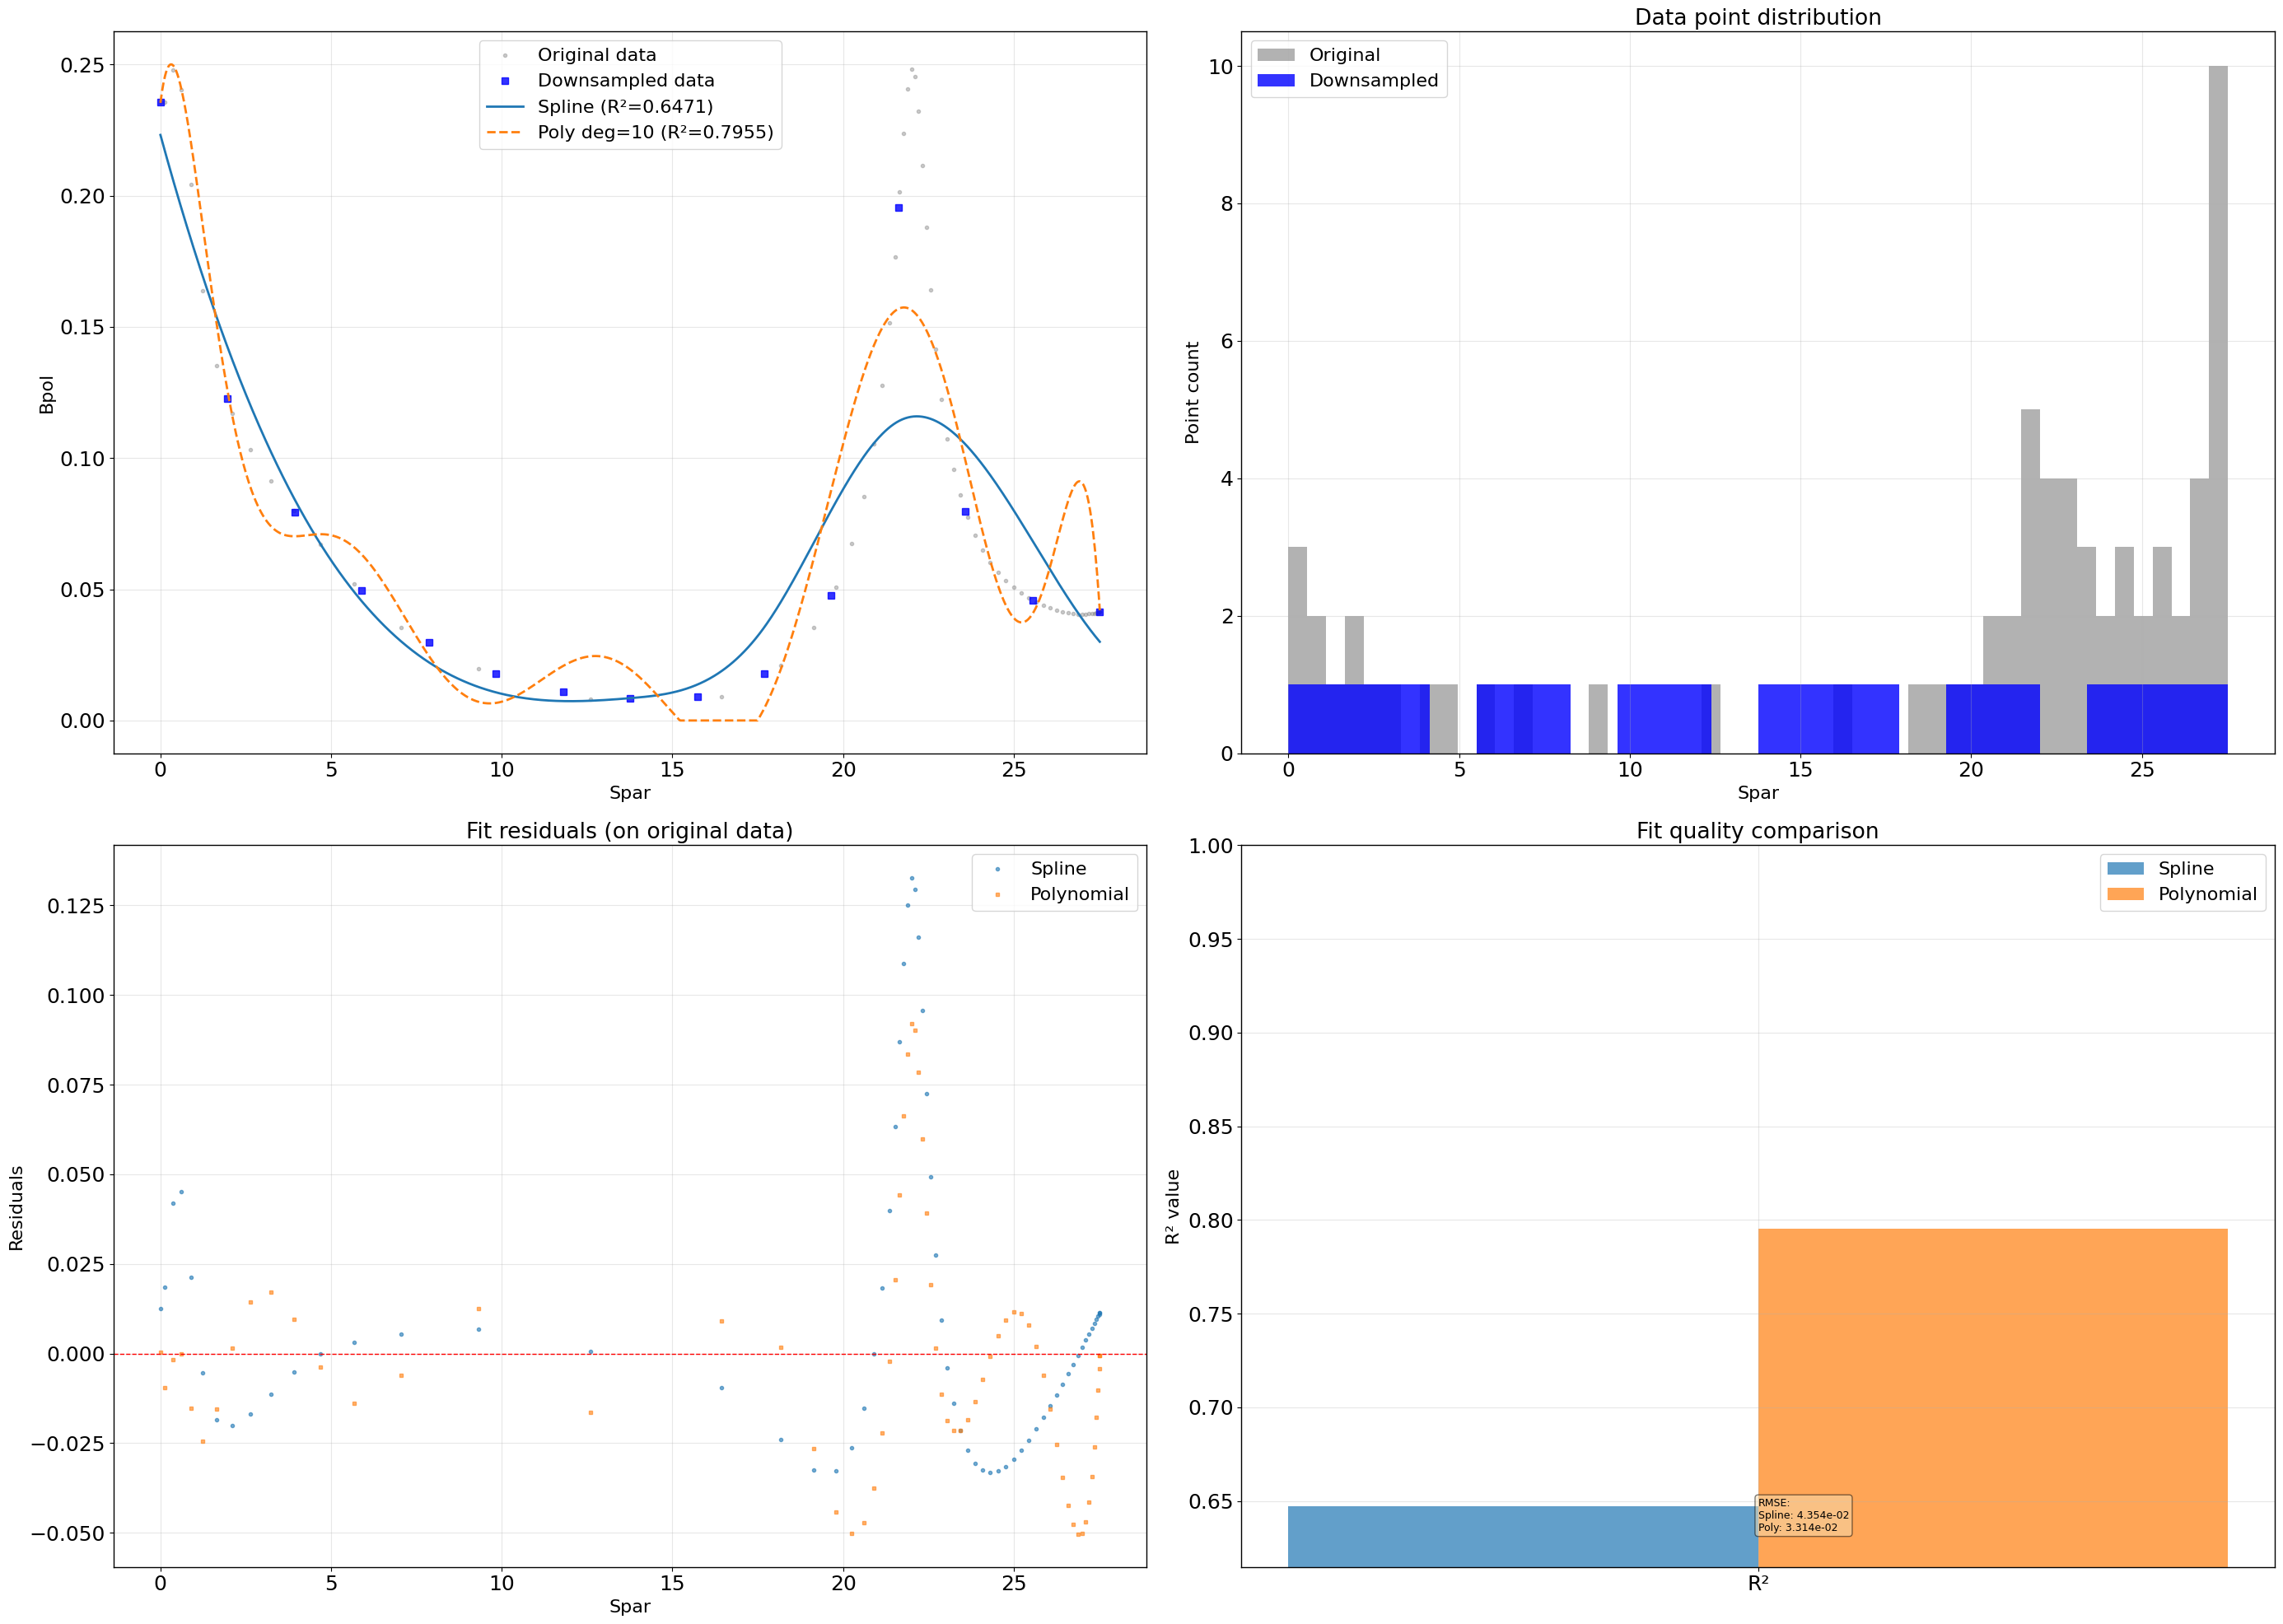

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, interp1d

def _nonnegative_wrapper(func):
    """Returns a function that clips any negative output to zero."""
    def wrapper(x):
        y = func(x)
        return np.clip(y, 0, None)
    return wrapper

def downsample_data(x_data, y_data, method='uniform', n_points=50):
    """
    Intelligently downsample data for better fitting.
    
    Parameters:
    -----------
    x_data, y_data : arrays
        Original data
    method : str
        'uniform' - uniform spacing in x
        'curvature' - adaptive sampling based on curvature
        'every_nth' - take every nth point
    n_points : int
        Target number of points (for 'uniform' and 'curvature')
    
    Returns:
    --------
    x_sampled, y_sampled : arrays
        Downsampled data
    """
    if method == 'uniform':
        # Uniform spacing in x
        x_min, x_max = x_data.min(), x_data.max()
        x_uniform = np.linspace(x_min, x_max, n_points)
        
        # Interpolate y values at uniform x points
        y_uniform = np.interp(x_uniform, x_data, y_data)
        
        return x_uniform, y_uniform
    
    elif method == 'curvature':
        # Adaptive sampling - keep more points where curvature is high
        # Estimate curvature using second differences
        if len(x_data) < 3:
            return x_data, y_data
        
        # Calculate approximate curvature
        dy = np.gradient(y_data, x_data)
        d2y = np.gradient(dy, x_data)
        curvature = np.abs(d2y)
        
        # Normalize curvature to [0, 1]
        curvature = curvature / (curvature.max() + 1e-10)
        
        # Sample probability proportional to curvature + baseline
        prob = 0.3 + 0.7 * curvature  # 30% uniform, 70% curvature-weighted
        prob = prob / prob.sum()
        
        # Sample indices
        n_sample = min(n_points, len(x_data))
        indices = np.random.choice(len(x_data), size=n_sample, replace=False, p=prob)
        indices = np.sort(indices)
        
        return x_data[indices], y_data[indices]
    
    elif method == 'every_nth':
        # Simply take every nth point
        stride = max(1, len(x_data) // n_points)
        indices = np.arange(0, len(x_data), stride)
        return x_data[indices], y_data[indices]
    
    else:
        raise ValueError(f"Unknown method: {method}")

def fit_with_spline(case, x, y, smoothing=None, plot=True, title=None, region="outer_lower", 
                    sepadd=0, target_first=False, guards=False, nonnegative_fit=True,
                    output_bout_format=True, poly_degree=None, variable_name=None,
                    downsample=True, downsample_method='uniform', n_sample_points=50):
    """
    Fit data using spline with optional intelligent downsampling.
    
    New Parameters:
    ---------------
    downsample : bool, optional
        Whether to downsample data before fitting (default: True)
    downsample_method : str, optional
        Method for downsampling: 'uniform', 'curvature', or 'every_nth' (default: 'uniform')
    n_sample_points : int, optional
        Number of points to keep after downsampling (default: 50)
    """
    # Get data from case
    data = case.get_1d_poloidal_data(
        params=[y],
        region=region,
        sepadd=sepadd,
        target_first=target_first,
        guards=guards
    )
    
    # Extract and clean data
    x_data = np.asarray(data[x])
    y_data = np.asarray(data[y])
    
    if np.ma.isMaskedArray(x_data):
        x_data = x_data.filled(np.nan)
    if np.ma.isMaskedArray(y_data):
        y_data = y_data.filled(np.nan)
    
    mask = (~np.isnan(x_data)) & (~np.isnan(y_data))
    x_data = x_data[mask]
    y_data = y_data[mask]
    
    sort_idx = np.argsort(x_data)
    x_data = x_data[sort_idx]
    y_data = y_data[sort_idx]
    
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    
    # Store original data for plotting
    x_orig, y_orig = x_data.copy(), y_data.copy()
    
    # Downsample if requested
    if downsample and len(x_data) > n_sample_points:
        print(f"Downsampling from {len(x_data)} to ~{n_sample_points} points using '{downsample_method}' method")
        x_data, y_data = downsample_data(x_data, y_data, method=downsample_method, n_points=n_sample_points)
        print(f"Using {len(x_data)} points for fitting")
    
    # Get x range for normalization
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    x_range = x_max - x_min
    
    # Normalize x to [0, 1] for better numerical stability
    x_normalized = (x_data - x_min) / x_range
    
    # Create spline on downsampled data
    if smoothing is None:
        base_spline = interp1d(x_data, y_data, kind='cubic', fill_value='extrapolate', assume_sorted=True)
        y_pred = base_spline(x_data)
    else:
        base_spline = UnivariateSpline(x_data, y_data, s=smoothing)
        y_pred = base_spline(x_data)
    
    if nonnegative_fit:
        spline = _nonnegative_wrapper(base_spline)
        y_pred = np.clip(y_pred, 0, None)
    else:
        spline = base_spline
    
    # Calculate spline fit quality on ORIGINAL data
    y_spline_orig = spline(x_orig)
    residuals_spline = y_orig - y_spline_orig
    ss_res_spline = np.sum(residuals_spline ** 2)
    ss_tot = np.sum((y_orig - np.mean(y_orig)) ** 2) if y_orig.size > 0 else np.nan
    r_squared_spline = 1 - (ss_res_spline / ss_tot) if ss_tot != 0 else np.nan
    rmse_spline = np.sqrt(np.mean(residuals_spline ** 2)) if y_orig.size > 0 else np.nan
    
    # Fit polynomial to the DOWNSAMPLED data
    if poly_degree is None:
        # Auto-select degree based on downsampled data size
        poly_degree = min(8, max(4, len(x_data) // 6))
    
    # Fit polynomial on normalized coordinates
    poly_coeffs = np.polyfit(x_normalized, y_data, poly_degree)
    poly = np.poly1d(poly_coeffs)
    
    # Calculate polynomial fit quality on ORIGINAL data
    x_orig_normalized = (x_orig - x_min) / x_range
    y_poly_orig = poly(x_orig_normalized)
    if nonnegative_fit:
        y_poly_orig = np.clip(y_poly_orig, 0, None)
    poly_residuals = y_orig - y_poly_orig
    poly_r_squared = 1 - (np.sum(poly_residuals**2) / ss_tot) if ss_tot != 0 else np.nan
    poly_rmse = np.sqrt(np.mean(poly_residuals ** 2))
    
    # Output BOUT++ format
    if output_bout_format:
        var_name = variable_name if variable_name else y
        
        print("\n" + "="*70)
        print(f"BOUT++ INPUT FILE FORMAT - Polynomial Fit for {y}")
        print("="*70)
        print(f"\n# Original data points: {len(x_orig)}")
        if downsample:
            print(f"# Downsampled to: {len(x_data)} points ({downsample_method} method)")
        print(f"# Polynomial degree: {poly_degree}")
        print(f"# Spline R² (on original data): {r_squared_spline:.6f}, RMSE: {rmse_spline:.6e}")
        print(f"# Polynomial R² (on original data): {poly_r_squared:.6f}, RMSE: {poly_rmse:.6e}")
        print(f"# {x} range: [{x_min:.6f}, {x_max:.6f}]")
        print(f"# Variable is normalized: y_norm = ({x} - {x_min:.6f}) / {x_range:.6f}")
        
        if nonnegative_fit and np.any(y_poly_orig < 0):
            print(f"# WARNING: Polynomial fit goes negative in some regions")
            print(f"# Min value: {y_poly_orig.min():.6e}")
            print(f"# Consider using max(0, expression) or increase smoothing")
        
        print("\n# Coefficients")
        for i, coeff in enumerate(poly_coeffs):
            print(f"coef{i} = {coeff:.8e}")
        
        # Build the expression
        print(f"\n# Polynomial expression")
        expr_parts = []
        for i in range(len(poly_coeffs)):
            power = len(poly_coeffs) - 1 - i
            if power == 0:
                expr_parts.append(f"coef{i}")
            else:
                expr_parts.append(f"y^{power}*coef{i}")
        
        expr = " + ".join(expr_parts)
        print(f"{var_name} = {expr}")
        
        print(f"\n# Where y is the normalized coordinate:")
        print(f"# y = ({x} - {x_min:.6f}) / {x_range:.6f}")
        
        if nonnegative_fit:
            print(f"\n# To enforce non-negativity, use:")
            print(f"# {var_name} = max(0, {expr})")
        
        print("\n" + "="*70)
        print("Copy the coefficients and expression above into your BOUT++ input file")
        print("="*70 + "\n")
    
    # Plotting
    if plot:
        x_fit = np.linspace(x_min, x_max, 1000)
        x_fit_normalized = (x_fit - x_min) / x_range
        y_fit_spline = spline(x_fit)
        y_fit_poly = poly(x_fit_normalized)
        if nonnegative_fit:
            y_fit_poly = np.clip(y_fit_poly, 0, None)
        
        fig, axes = plt.subplots(2, 2, figsize=(28, 20))
        
        # Main plot
        ax1 = axes[0, 0]
        ax1.plot(x_orig, y_orig, 'o', label='Original data', markersize=3, alpha=0.4, color='gray')
        if downsample:
            ax1.plot(x_data, y_data, 's', label='Downsampled data', markersize=6, alpha=0.8, color='blue')
        ax1.plot(x_fit, y_fit_spline, '-', label=f'Spline (R²={r_squared_spline:.4f})', linewidth=2)
        ax1.plot(x_fit, y_fit_poly, '--', label=f'Poly deg={poly_degree} (R²={poly_r_squared:.4f})', linewidth=2)
        ax1.set_xlabel(x)
        ax1.set_ylabel(y)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        if title:
            ax1.set_title(title)
        
        # Data distribution
        ax2 = axes[0, 1]
        ax2.hist(x_orig, bins=50, alpha=0.6, label='Original', color='gray')
        if downsample:
            ax2.hist(x_data, bins=20, alpha=0.8, label='Downsampled', color='blue')
        ax2.set_xlabel(x)
        ax2.set_ylabel('Point count')
        ax2.set_title('Data point distribution')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Residuals
        ax3 = axes[1, 0]
        ax3.plot(x_orig, residuals_spline, 'o', markersize=3, label='Spline', alpha=0.6)
        ax3.plot(x_orig, poly_residuals, 's', markersize=3, label='Polynomial', alpha=0.6)
        ax3.axhline(y=0, color='r', linestyle='--', linewidth=1)
        ax3.set_xlabel(x)
        ax3.set_ylabel('Residuals')
        ax3.set_title('Fit residuals (on original data)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # Error comparison
        ax4 = axes[1, 1]
        metrics = ['R²', 'RMSE']
        spline_vals = [r_squared_spline, rmse_spline]
        poly_vals = [poly_r_squared, poly_rmse]
        
        x_pos = np.arange(len(metrics))
        width = 0.35
        
        # For R², plot directly; for RMSE show on log scale if needed
        ax4_r2 = ax4
        ax4_r2.bar(x_pos[0] - width/2, spline_vals[0], width, label='Spline', alpha=0.7)
        ax4_r2.bar(x_pos[0] + width/2, poly_vals[0], width, label='Polynomial', alpha=0.7)
        ax4_r2.set_ylabel('R² value')
        ax4_r2.set_ylim([min(spline_vals[0], poly_vals[0]) * 0.95, 1.0])
        ax4_r2.set_xticks([0])
        ax4_r2.set_xticklabels(['R²'])
        ax4_r2.legend()
        ax4_r2.grid(True, alpha=0.3)
        ax4_r2.set_title('Fit quality comparison')
        
        # Add RMSE as text
        ax4_r2.text(0.5, 0.05, f'RMSE:\nSpline: {rmse_spline:.3e}\nPoly: {poly_rmse:.3e}',
                   transform=ax4_r2.transAxes, fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    
    return spline, poly_coeffs, r_squared_spline, rmse_spline

# Usage examples:

# # Example 1: Uniform downsampling (recommended)
# spline, coeffs, r2, rmse = fit_with_spline(
#     case, 'Spar', 'Bpol',
#     smoothing=0.01,
#     region="outer_lower",
#     downsample=True,
#     downsample_method='uniform',
#     n_sample_points=50,
#     poly_degree=6
# )

# # Example 2: Curvature-based downsampling (keeps more points where curve changes rapidly)
# spline, coeffs, r2, rmse = fit_with_spline(
#     case, 'Spar', 'Bpol',
#     smoothing=0.01,
#     region="outer_lower",
#     downsample=True,
#     downsample_method='curvature',
#     n_sample_points=40,
#     poly_degree=6
# )

# # Example 3: No downsampling (use all points)
# spline, coeffs, r2, rmse = fit_with_spline(
#     case, 'Spar', 'Bpol',
#     smoothing=0.01,
#     region="outer_lower",
#     downsample=False
# )

# Example 4: Compare different downsampling amounts
# for n in [30, 50, 100]:
#     print(f"\n{'='*50}")
#     print(f"Testing with {n} sample points")
#     print(f"{'='*50}")
#     fit_with_spline(
#         case, 'Spar', 'Bpol',
#         smoothing=0.01,
#         region="outer_lower",
#         downsample=True,
#         n_sample_points=n,
#         poly_degree=6,
#         plot=True
#     )

spline, coeffs, r2, rmse = fit_with_spline(
    case, 'Spar', 'Bpol',
    smoothing=0.01,
    region="outer_lower",
    downsample=True,
    downsample_method='uniform',
    n_sample_points=15,
    poly_degree=10  # Higher degree to capture the peak
)

In [9]:
# def export_for_fieldline_geometry(profile, output_file='bpol_expression.txt', poly_degree=6):
#     """
#     Export profile as polynomial expression for fieldline_geometry component.
#     The expression will be a function of lpar.
    
#     Parameters:
#     -----------
#     profile : SplineFieldProfile
#         Fitted profile object
#     output_file : str
#         Output filename
#     poly_degree : int
#         Degree of polynomial to fit
#     """
    
#     # Fit polynomial to the spline (if not already done)
#     x_normalized = (profile.x_data - profile.x_data.min()) / (profile.x_data.max() - profile.x_data.min())
#     poly_coeffs = np.polyfit(x_normalized, profile.y_data, poly_degree)
    
#     # Calculate fit quality
#     poly = np.poly1d(poly_coeffs)
#     y_pred = poly(x_normalized)
#     residuals = profile.y_data - y_pred
#     r_squared = 1 - (np.sum(residuals**2) / np.sum((profile.y_data - profile.y_data.mean())**2))
#     rmse = np.sqrt(np.mean(residuals**2))
    
#     x_min = profile.x_data.min()
#     x_max = profile.x_data.max()
#     x_range = x_max - x_min
    
#     print(f"\n{'='*70}")
#     print(f"EXPRESSION FOR fieldline_geometry COMPONENT")
#     print(f"{'='*70}")
#     print(f"Field: {profile.field_name}")
#     print(f"Polynomial degree: {poly_degree}")
#     print(f"R² = {r_squared:.6f}, RMSE = {rmse:.6e}")
#     print(f"lpar range: [{x_min:.6f}, {x_max:.6f}] m")
#     print(f"\nAdd this to your input file:\n")
#     print(f"[fieldline_geometry]")
#     print(f"# Polynomial fit for {profile.field_name} as function of lpar")
#     print(f"# R² = {r_squared:.6f}")
    
#     # Create the expression using lpar
#     # Normalize lpar to [0,1] range matching our fit
#     # lpar_norm = (lpar - x_min) / (x_max - x_min)
    
#     # Build polynomial expression
#     expr_parts = []
#     for i, coef in enumerate(poly_coeffs):
#         power = poly_degree - i
#         if abs(coef) < 1e-15:
#             continue
#         if power == 0:
#             expr_parts.append(f"{coef:.12e}")
#         elif power == 1:
#             expr_parts.append(f"{coef:.12e}*((lpar - {x_min:.6f})/{x_range:.6f})")
#         else:
#             expr_parts.append(f"{coef:.12e}*((lpar - {x_min:.6f})/{x_range:.6f})^{power}")
    
#     expr = " + ".join(expr_parts).replace("+ -", "- ")
    
#     print(f"{profile.field_name} = {expr}")
    
#     # Show simpler form with coefficients
#     print(f"\n# Alternative with named coefficients:")
#     print(f"# Define these first:")
#     print(f"lpar_min = {x_min:.6f}")
#     print(f"lpar_range = {x_range:.6f}")
#     for i, coef in enumerate(poly_coeffs):
#         print(f"c{i} = {coef:.12e}")
    
#     print(f"\n# Then use:")
#     coef_expr_parts = []
#     for i in range(len(poly_coeffs)):
#         power = poly_degree - i
#         if power == 0:
#             coef_expr_parts.append(f"c{i}")
#         elif power == 1:
#             coef_expr_parts.append(f"c{i}*((lpar - lpar_min)/lpar_range)")
#         else:
#             coef_expr_parts.append(f"c{i}*((lpar - lpar_min)/lpar_range)^{power}")
    
#     coef_expr = " + ".join(coef_expr_parts)
#     print(f"{profile.field_name} = {coef_expr}")
    
#     print(f"\n{'='*70}\n")
    
#     # Save to file
#     with open(output_file, 'w') as f:
#         f.write(f"[fieldline_geometry]\n")
#         f.write(f"# Polynomial fit for {profile.field_name}\n")
#         f.write(f"# R² = {r_squared:.6f}, RMSE = {rmse:.6e}\n")
#         f.write(f"# Degree: {poly_degree}\n\n")
#         f.write(f"# Direct expression (copy this line):\n")
#         f.write(f"{profile.field_name} = {expr}\n\n")
#         f.write(f"# Or use coefficients:\n")
#         f.write(f"lpar_min = {x_min:.6f}\n")
#         f.write(f"lpar_range = {x_range:.6f}\n")
#         for i, coef in enumerate(poly_coeffs):
#             f.write(f"c{i} = {coef:.12e}\n")
#         f.write(f"{profile.field_name} = {coef_expr}\n")
    
#     print(f"Saved to {output_file}\n")
    
#     return expr, poly_coeffs, r_squared

# # Usage:
# bpol_profile = SplineFieldProfile(
#     case, 
#     x_coord='Spar',
#     field_name='Bpol',
#     region="outer_lower",
#     sepadd=0
# )

# # Fit spline
# bpol_profile.fit(
#     smoothing=0.01,
#     downsample=True,
#     n_sample_points=50,
#     nonnegative=True,
#     plot=True
# )

# # Export as expression for the component
# expr, coeffs, r2 = export_for_fieldline_geometry(
#     bpol_profile, 
#     'bpol_expression.txt',
#     poly_degree=6
# )

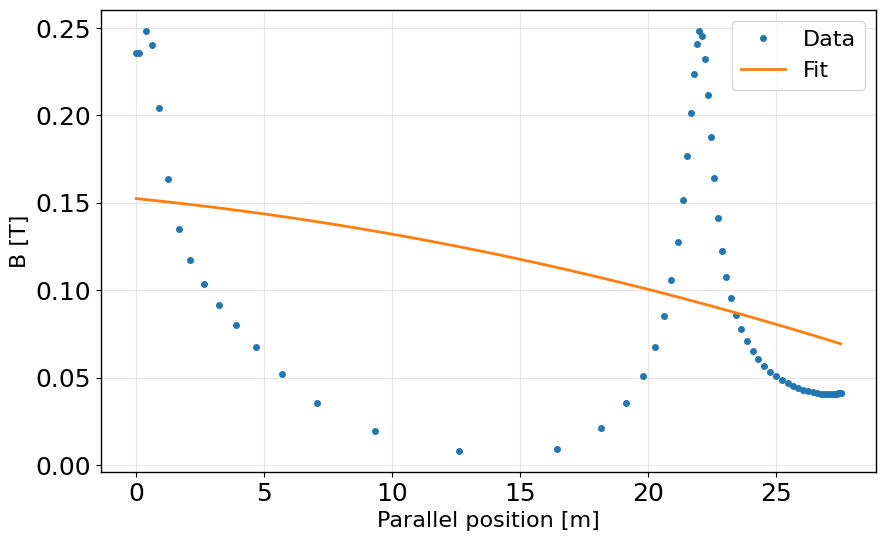

Fitted parameters:
Amplitude: 175.6115
Center: -13.0876 m
Width: 1249.7518 m
Offset: -175.4495 T


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Load your data (adjust based on your data format)
# data = np.loadtxt('your_data.txt')
x = fline['Spar']  # parallel position
y = fline['Bpol']  # B field

# 2. Define fitting function(s)
# Option A: Gaussian
def gaussian(x, amplitude, center, width, offset):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2)) + offset

# Option B: Super-Gaussian (better for flatter tops)
def super_gaussian(x, amplitude, center, width, power, offset):
    return amplitude * np.exp(-((x - center)/width)**(2*power)) + offset

# 3. Fit the data
# Initial guess for parameters [amplitude, center, width, offset]
p0_gauss = [0.5, 15, 5, 0.4]  # adjust based on your data

popt, pcov = curve_fit(gaussian, x, y, p0=p0_gauss)

# 4. Plot results
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = gaussian(x_fit, *popt)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'o', label='Data', markersize=4)
plt.plot(x_fit, y_fit, '-', label='Fit', linewidth=2)
plt.xlabel('Parallel position [m]')
plt.ylabel('B [T]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Fitted parameters:")
print(f"Amplitude: {popt[0]:.4f}")
print(f"Center: {popt[1]:.4f} m")
print(f"Width: {popt[2]:.4f} m")
print(f"Offset: {popt[3]:.4f} T")

## $\lambda_{int}$

We need to find $\lambda_{int}$ from $\lambda_q$ and any transport broadening $S$. To do this we need to take these both from the SOLPS case, $\lambda_a$ will be relatively easy as we just need to fit an exponential to the parallel heat flux at the OMP. However $S$ will be more challenging, especially for detached cases, David Moulton suggests this:

I suppose it would make an Eich fit to "fht(ix,:,1)/gs(ix,:,1)" (poloidal energy flux / poloidal contact area) at some location ix just upstream of the detachment front? Then take S from the fit.

/var/folders/f_/7qkzjr_13411kq7vkyxvnb5r0000gn/T/ipykernel_8119/322762695.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


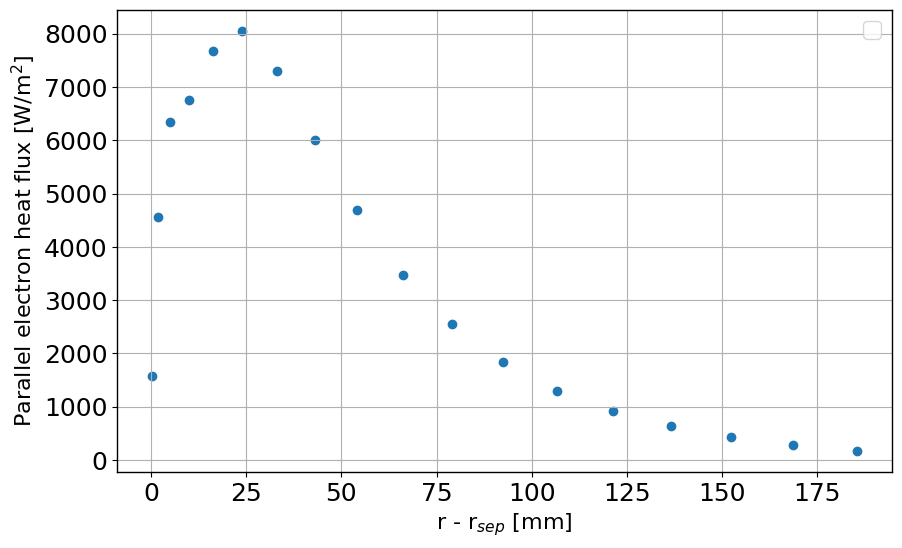

In [11]:
fline = case.get_1d_radial_data(
    ["Te", "ne", 'Nn', "Pe", 'fhex_total', 'fhix_total', 'fhey_total'], 
    region="outer_lower_detachment_front",  # outer lower divertor leg
    keep_geometry = True

)

sep_indx = np.argmin(np.abs(fline['dist'] - 0)) 

fline = fline.iloc[sep_indx:]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(fline['dist'] * 1000, fline['fhex_total']) 
# case.plot_2d("fhex_total", ax=ax, logscale=True, cbar=True)   
# ax.plot(fline['dist'], fline['fhix_total'])
ax.set_xlabel(r"r - r$_{sep}$ [mm]")
ax.set_ylabel(r"Parallel electron heat flux [W/m$^2$]")
# ax.set_ylabel(r"Te [eV]")
# ax.set_xlim(0, 10)
# ax.set_ylim(0, 25000)

# ax.set_ylim(0,)
ax.legend()


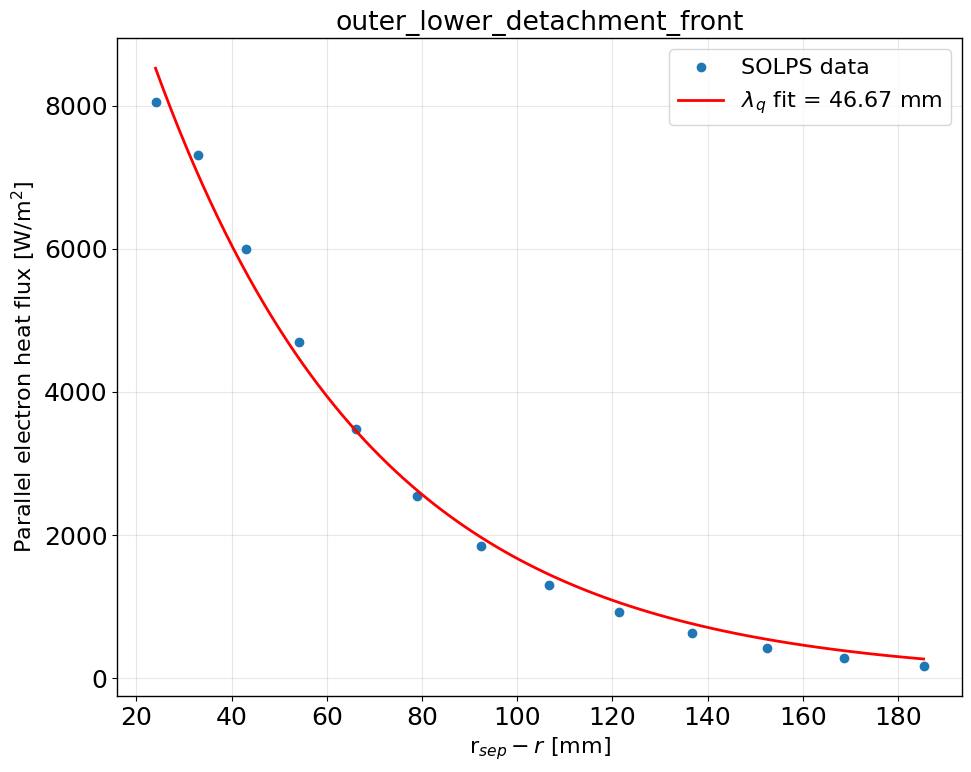

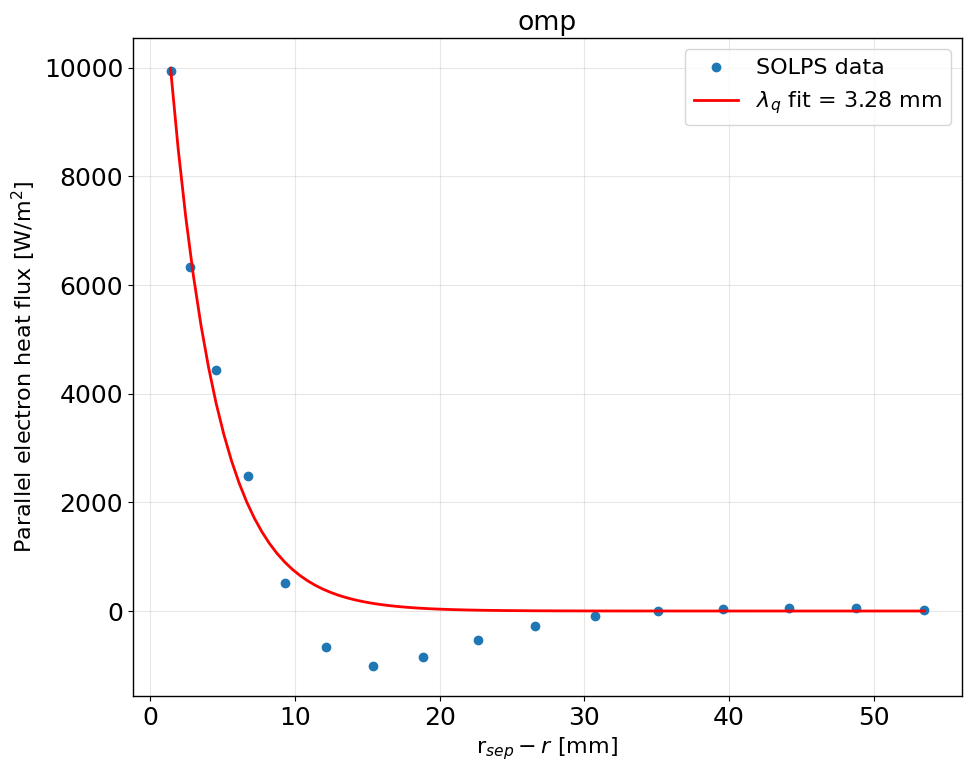

In [27]:
def get_lambda_q(case, region="omp", plot=True, range=(0.0, None), go_from_peak=False):
    fline = case.get_1d_radial_data(
        ["Te", "ne", 'Nn', "Pe", 'fhex_total', 'fhix_total', 'fhey_total'], 
        region=region,
        keep_geometry=True
    )
    
    ds = fline.copy()

    # Filter lower bound
    if range[0] is not None:
        sep_indx = np.searchsorted(ds['dist'].values, range[0], side='right')
        ds = ds.iloc[sep_indx:]

    # Filter upper bound
    if range[1] is not None:
        upper_indx = np.searchsorted(ds['dist'].values, range[1], side='right')
        ds = ds.iloc[:upper_indx]
    
    # Optionally clip data to start from peak q_parallel value,
    # but only after range filter
    if go_from_peak:
        q_parallel = ds['fhex_total']
        peak_idx = q_parallel.idxmax()
        # Clip to start from the peak, keep all rows from peak_idx onwards
        # idxmax returns the index in the original DataFrame, need to get correct position
        pos_from_peak = ds.index.get_loc(peak_idx)
        ds = ds.iloc[pos_from_peak:]


    # Calculate parallel heat flux
    q_parallel = ds['fhex_total']
    
    # fit exponential to parallel heat flux
    def fit(r, a, lmq):
        return a * np.exp(-r/lmq)

    # Provide initial guesses for better convergence
    p0 = [q_parallel.iloc[0], 0.005]  # initial guess
    
    # fit parameters
    popt, pcov = cp.optimize.curve_fit(fit, ds['dist'], q_parallel, p0=p0)
    a, lmq = popt

    # calculate lambda_q
    lambda_q = lmq  # lambda_q is the decay length in meters
    
    if plot:
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Plot data
        ax.plot(ds['dist'] * 1000, q_parallel, 'o', label='SOLPS data', markersize=6)
        
        # Plot fit
        r_fit = np.linspace(ds['dist'].min(), ds['dist'].max(), 100)
        q_fit = fit(r_fit, a, lmq)
        ax.plot(r_fit * 1000, q_fit, 'r-', linewidth=2, 
                label=fr'$\lambda_q$ fit = {lambda_q*1000:.2f} mm')
        
        ax.set_xlabel(r"r$_{sep} - r$ [mm]")
        ax.set_ylabel(r"Parallel electron heat flux [W/m$^2$]")
        ax.set_title(f"{region}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return lambda_q, a, lmq

    # Use default range (all data)
# lambda_q, a, lmq = get_lambda_q(case, region='omp')

# Use specific range
lambda_q, a, lmq = get_lambda_q(case, region='outer_lower_detachment_front', range=(0.0, None), go_from_peak=True)

lambda_q, a, lmq = get_lambda_q(case, region='omp', go_from_peak=True,range=(0.0, None))


# Use only lower bound
# lambda_q, a, lmq = get_lambda_q(case, region='omp', range=(0.01, None))

0.9585074675 -1.8087062250000001


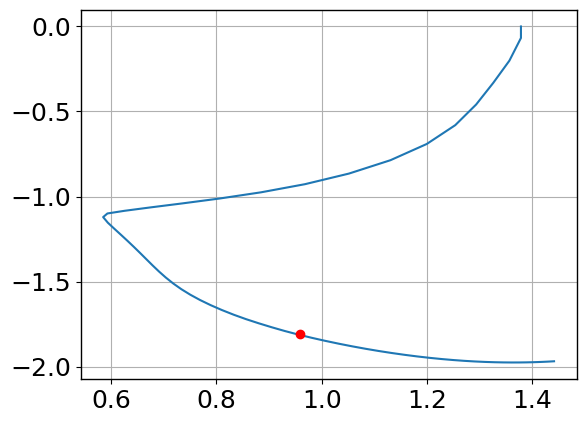

In [13]:
# we'll probably have to find the detachment front to know where to get S from

def get_detachment_RZ(case):
    fline = case.get_1d_poloidal_data(
        params = ["R", "Z", "Te"],
        region = "outer_lower",
        sepadd = 2,
        target_first = False,
        guards = False
    )
    
    # find the index of the detachment front
    det_indx = np.argmin(np.abs(fline['Te'] - 5))
    return fline.iloc[det_indx]['R'], fline.iloc[det_indx]['Z']

det_R, det_Z = get_detachment_RZ(case)

print(det_R, det_Z) 

fline = case.get_1d_poloidal_data(
    params = ["R", "Z", "Te"],
    region = "outer_lower",
    sepadd = 0,
    target_first = False,
    guards = False
)


fig,ax = plt.subplots()
ax.plot(fline['R'], fline['Z'])
ax.plot(det_R, det_Z, 'ro')


## Getting radial data at the detachment front


In [14]:
# Now get_1d_radial_data supports detachment front directly!
# Just specify region as "outer_lower_detachment_front" (or inner_lower, outer_upper, inner_upper)

radial_data = case.get_1d_radial_data(
    params=["Te", "ne", "Pe", "Td+", "Pd+", "Na", "Nm", "Nn",'fhex_total', 'fhix_total', 'fhey_total', 'hy'],
    region="outer_lower_detachment_front",
    Te_threshold=5,    # Temperature threshold to define front (eV)
    sepadd=2,          # SOL ring to search for front
    keep_geometry=True,
    verbose=True
)

# Display first few rows
print("\nRadial profile at detachment front:")
radial_data.head(10)

Detachment front found at R=0.959 m, Z=-1.809 m
Te at front: 4.93 eV (threshold: 5 eV)
Poloidal grid index: 159

Radial profile at detachment front:


,dist,sep,apar,vol,hx,hy,R,Z,Btot,Bpol,...,ne,Pe,Td+,Pd+,Na,Nm,Nn,fhex_total,fhix_total,fhey_total
1,-0.071883,0,0.008372,0.001872,0.033769,0.009795,0.909504,-1.866294,0.583701,0.088145,...,1.381346e+18,0.241848,1.677610,0.371282,2.853908e+18,1.678952e+19,3.643295e+19,-24.115883,-2.309058,-4.845707
2,-0.062658,0,0.007573,0.001703,0.034420,0.008654,0.917181,-1.861116,0.579017,0.088647,...,2.773692e+18,0.567670,1.779243,0.790686,2.946256e+18,1.358326e+19,3.011277e+19,-34.925954,-2.613900,-3.386798
3,-0.054385,0,0.007068,0.001544,0.033870,0.007892,0.923836,-1.856158,0.575043,0.089155,...,4.115065e+18,0.918254,1.843084,1.215156,3.019048e+18,1.117190e+19,2.536285e+19,-36.199533,-1.661227,-3.611424
4,-0.046999,0,0.006307,0.001395,0.034714,0.006880,0.929378,-1.851239,0.571772,0.089742,...,5.383376e+18,1.280258,1.911226,1.648455,3.082244e+18,9.274821e+18,2.163189e+19,-23.648274,7.045260,-4.355707
5,-0.040410,0,0.005842,0.001238,0.033656,0.006298,0.933757,-1.846289,0.569252,0.090450,...,6.740314e+18,1.704462,1.982989,2.141464,3.140023e+18,7.757947e+18,1.865592e+19,-9.232898,26.779357,-6.968179
6,-0.034535,0,0.005132,0.001088,0.034063,0.005453,0.937309,-1.841622,0.567309,0.091161,...,8.480184e+18,2.260105,2.042729,2.775405,3.184849e+18,6.552551e+18,1.628995e+19,0.599490,41.350171,-12.761312
7,-0.029364,0,0.004656,0.000969,0.033768,0.004888,0.940366,-1.837415,0.565611,0.091789,...,1.058022e+19,2.959374,2.099247,3.558513,3.227937e+18,5.554988e+18,1.433791e+19,9.644583,58.894867,-21.050840
8,-0.024764,0,0.004149,0.000853,0.033657,0.004313,0.942994,-1.833614,0.564155,0.092349,...,1.301813e+19,3.798907,2.150053,4.484439,3.261657e+18,4.742897e+18,1.274745e+19,11.497831,68.712636,-31.729376
9,-0.020737,0,0.003627,0.000739,0.033612,0.003741,0.945217,-1.830224,0.562908,0.092844,...,1.556854e+19,4.723962,2.207308,5.505807,3.277941e+18,4.069670e+18,1.141728e+19,10.656743,76.338087,-44.263528
10,-0.017207,0,0.003237,0.000636,0.032592,0.003318,0.947067,-1.827237,0.561957,0.093278,...,1.803024e+19,5.682405,2.276255,6.575562,3.293488e+18,3.534722e+18,1.036293e+19,1.411699,81.430008,-58.391827


Detachment front found at R=0.959 m, Z=-1.809 m
Te at front: 4.93 eV (threshold: 5 eV)
Poloidal grid index: 159


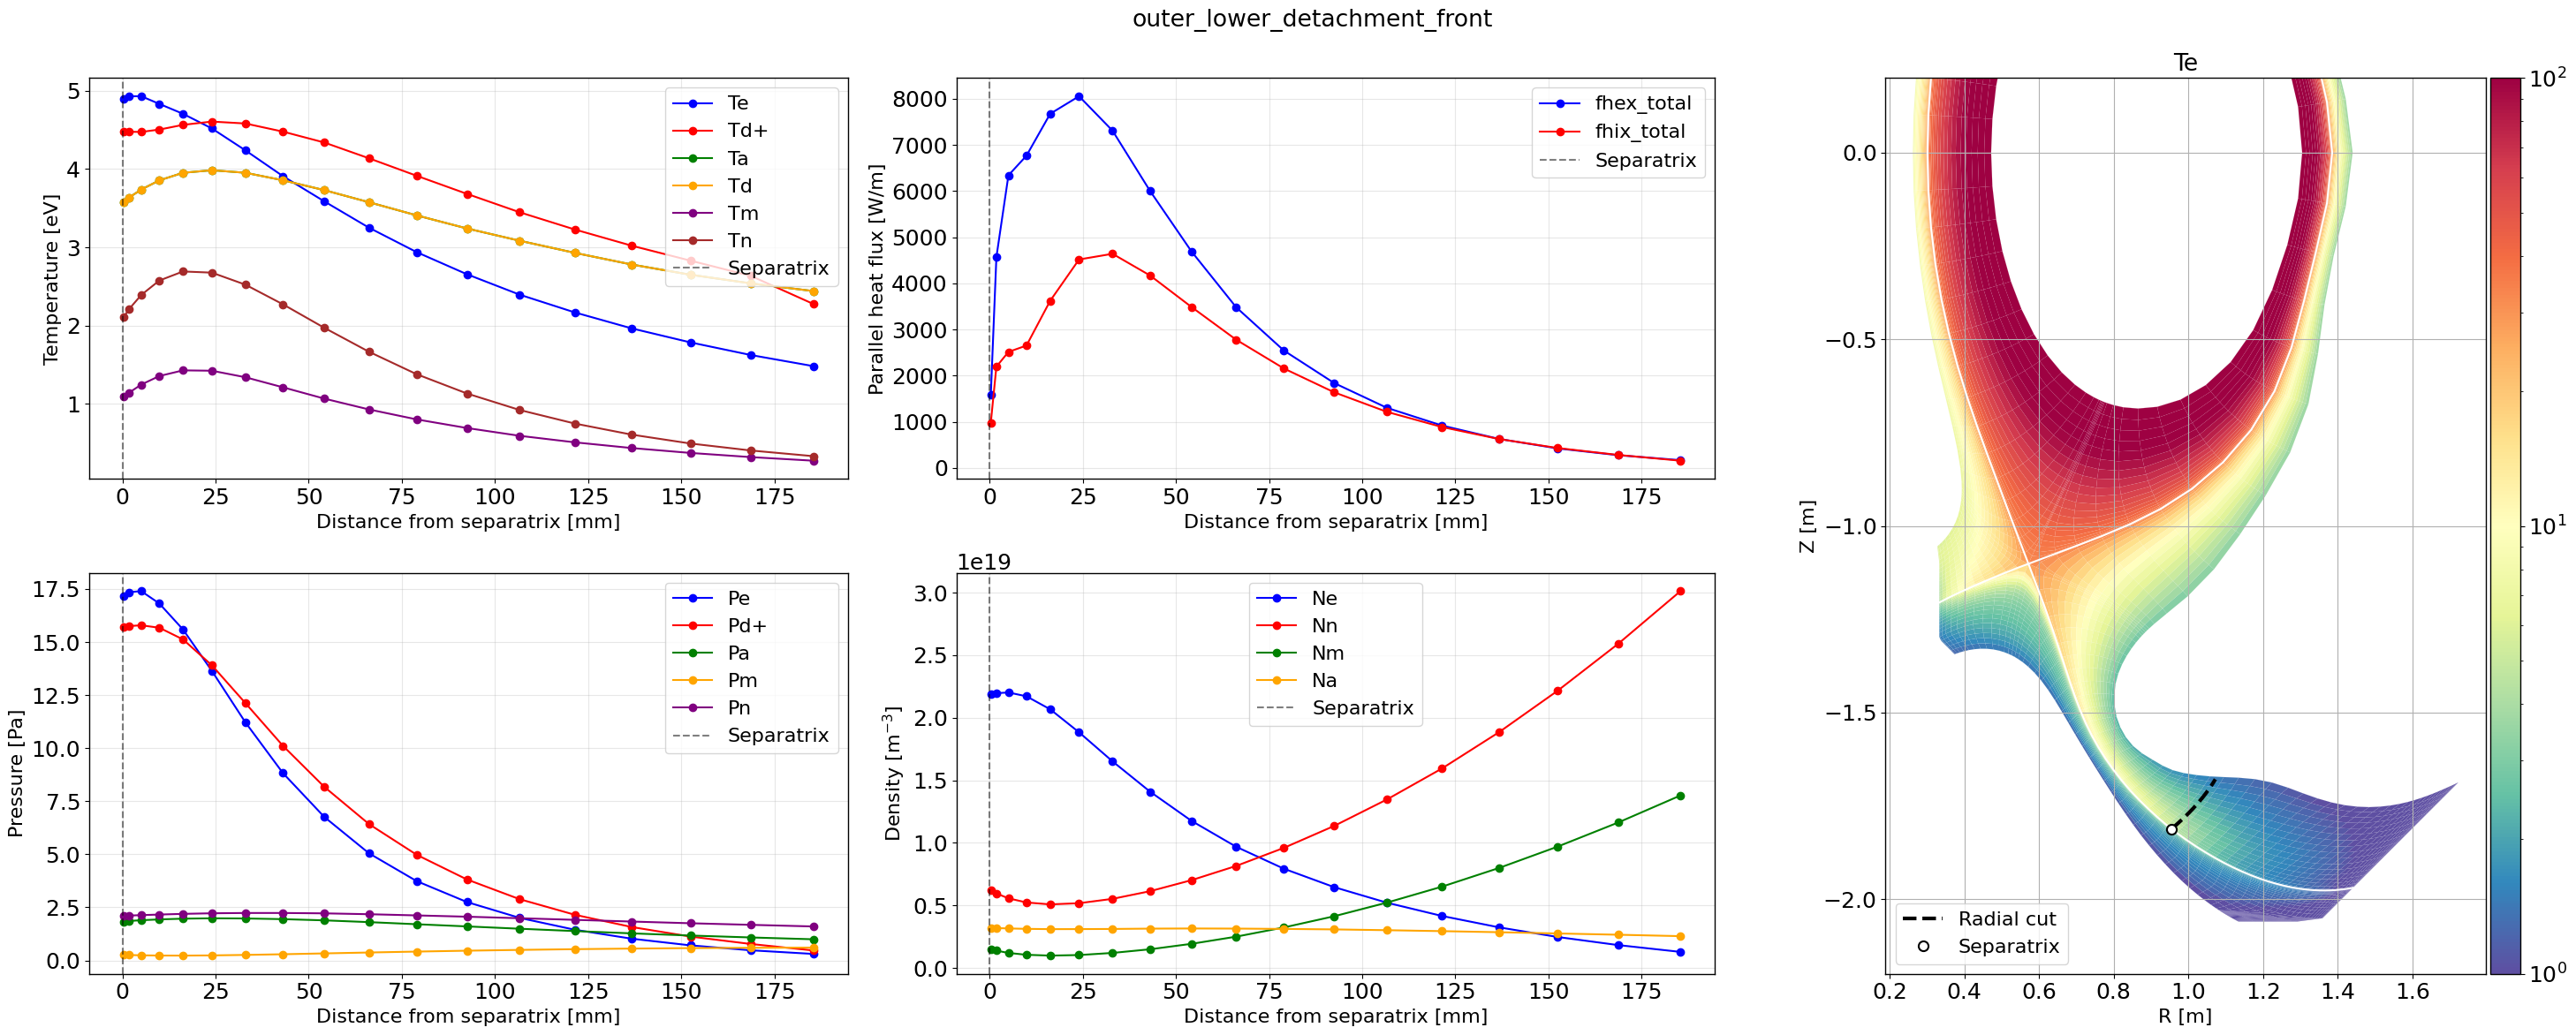

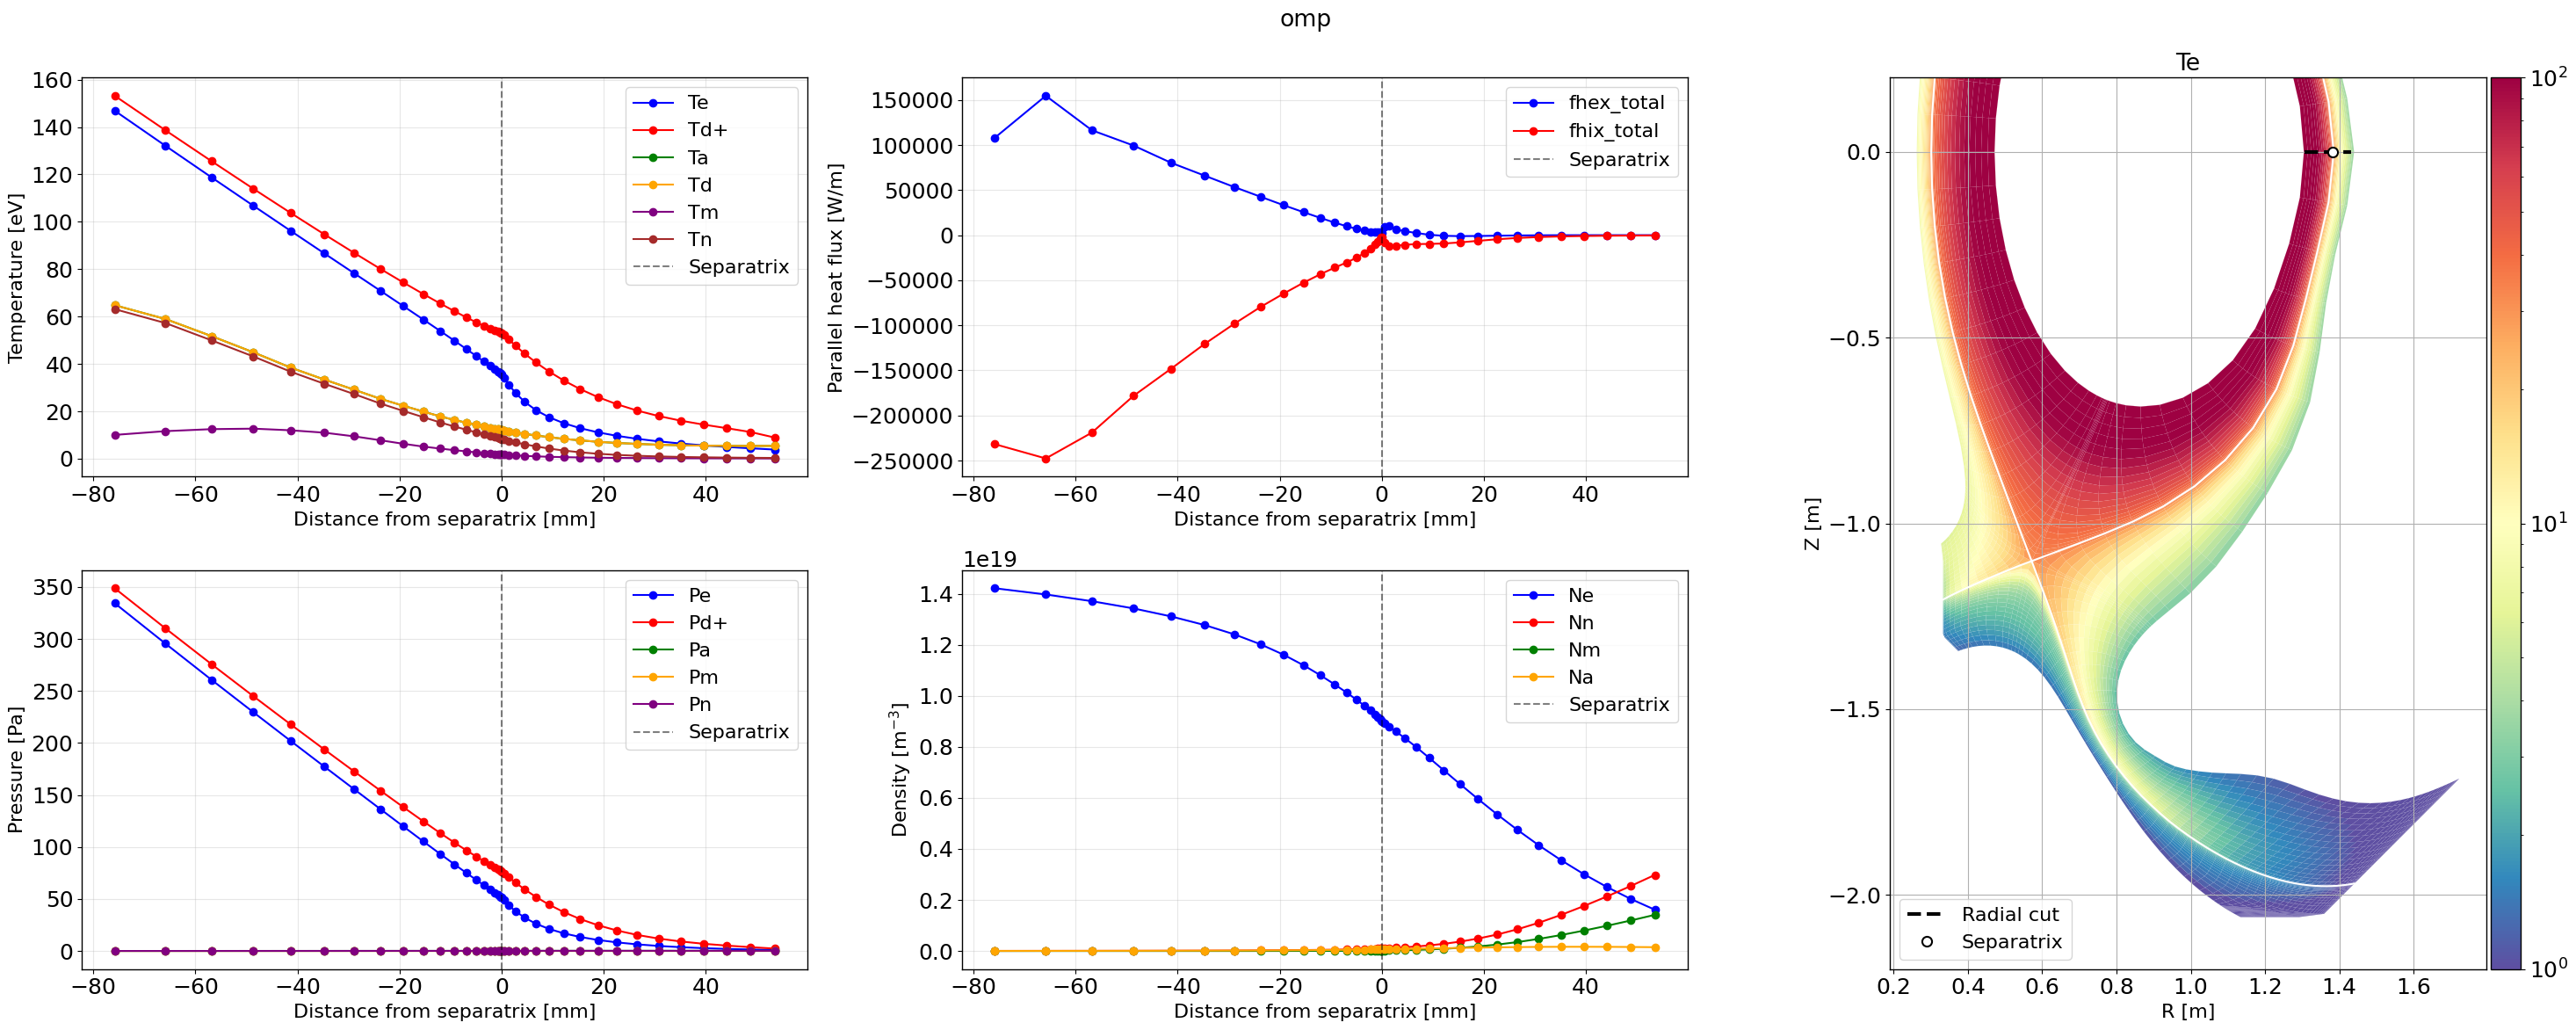

In [32]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_radial_profiles(case, param_2d = 'Te', region='omp', Te_threshold=5, sepadd=2, keep_geometry=True, verbose=True, zoom = False, grid_only = False, cfr_only=False):
    """
    Plots a summary of radial plasma profiles and their 2D location for a given region.

    Parameters:
        case: SOLPS case object
        region: Region string (e.g., 'omp', 'outer_lower_detachment_front', etc.)
        Te_threshold: Te threshold for detachment front (if needed)
        sepadd: SOL ring to search for front
        keep_geometry: If True, retain R/Z data in DataFrame
        verbose: Print more information from .get_1d_radial_data
        cfr_only: If True, only plot profile points where dist >= 0
    """
    # Create figure with custom gridspec layout
    fig = plt.figure(figsize=(30, 12))
    gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 1])

    # Create axes - 4 plots on left (2x2), 1 tall plot on right
    ax_temp = fig.add_subplot(gs[0, 0])
    ax_heat = fig.add_subplot(gs[0, 1])
    ax_press = fig.add_subplot(gs[1, 0])
    ax_dens = fig.add_subplot(gs[1, 1])
    ax_2d = fig.add_subplot(gs[:, 2])  # Spans both rows

    radial_data = case.get_1d_radial_data(
        params=['Te', 'Td+', 'Ta', 'Td', 'Tm', 'Tn', 'Pe', 'Pd+', 'Pa', 'Pn', 'Pm',
                'Ne', 'Nn', 'Nm', 'Na', 'fhex_total',
                'fhix_total', 'fhey_total', 'hy', 'R', 'Z'],
        region=region,
        Te_threshold=Te_threshold,
        sepadd=sepadd,
        keep_geometry=keep_geometry,
        verbose=verbose
    )
    fig.suptitle(f'{region}')

    # Apply filter for dist >= 0 if requested by cfr_only
    if cfr_only:
        radial_data_profile = radial_data[radial_data['dist'] >= 0].copy()
    else:
        radial_data_profile = radial_data

    # Plot 1: Temperature profiles
    ax_temp.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Te'], 'o-', label='Te', color='blue')
    ax_temp.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Td+'], 'o-', label='Td+', color='red')
    ax_temp.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Ta'], 'o-', label='Ta', color='green')
    ax_temp.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Td'], 'o-', label='Td', color='orange')
    ax_temp.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Tm'], 'o-', label='Tm', color='purple')
    ax_temp.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Tn'], 'o-', label='Tn', color='brown')
    ax_temp.axvline(0, color='k', linestyle='--', alpha=0.5, label='Separatrix')
    ax_temp.set_xlabel('Distance from separatrix [mm]')
    ax_temp.set_ylabel('Temperature [eV]')
    ax_temp.legend()
    ax_temp.grid(True, alpha=0.3)

    # Plot 2: Parallel heat flux
    ax_heat.plot(radial_data_profile['dist'] * 1000, radial_data_profile['fhex_total'], 'o-', label='fhex_total', color='blue')
    ax_heat.plot(radial_data_profile['dist'] * 1000, radial_data_profile['fhix_total'], 'o-', label='fhix_total', color='red')
    ax_heat.axvline(0, color='k', linestyle='--', alpha=0.5, label='Separatrix')
    ax_heat.set_xlabel('Distance from separatrix [mm]')
    ax_heat.set_ylabel('Parallel heat flux [W/m]')
    ax_heat.legend()
    ax_heat.grid(True, alpha=0.3)

    # Plot 3: Pressure profiles
    ax_press.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Pe'], 'o-', label='Pe', color='blue')
    ax_press.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Pd+'], 'o-', label='Pd+', color='red')
    ax_press.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Pa'], 'o-', label='Pa', color='green')
    ax_press.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Pm'], 'o-', label='Pm', color='orange')
    ax_press.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Pn'], 'o-', label='Pn', color='purple')
    ax_press.axvline(0, color='k', linestyle='--', alpha=0.5, label='Separatrix')
    ax_press.set_xlabel('Distance from separatrix [mm]')
    ax_press.set_ylabel('Pressure [Pa]')
    ax_press.legend()
    ax_press.grid(True, alpha=0.3)

    # Plot 4: Density profiles
    ax_dens.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Ne'], 'o-', label='Ne', color='blue')
    ax_dens.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Nn'], 'o-', label='Nn', color='red')
    ax_dens.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Nm'], 'o-', label='Nm', color='green')
    ax_dens.plot(radial_data_profile['dist'] * 1000, radial_data_profile['Na'], 'o-', label='Na', color='orange')
    ax_dens.axvline(0, color='k', linestyle='--', alpha=0.5, label='Separatrix')
    ax_dens.set_xlabel('Distance from separatrix [mm]')
    ax_dens.set_ylabel(r'Density [m$^{-3}$]')
    ax_dens.legend()
    ax_dens.grid(True, alpha=0.3)

    # Plot 5: 2D cross-section with radial cut location
    vmin = 1
    vmax = 100
    case.plot_2d(param_2d, ax=ax_2d, logscale=True, cbar=True, vmin=vmin, vmax=vmax, grid_only = grid_only)

    # Plot the radial cut location -- ONLY include dist >=0 if cfr_only is True
    if cfr_only:
        R_cut = radial_data.loc[radial_data['dist'] >= 0, 'R']
        Z_cut = radial_data.loc[radial_data['dist'] >= 0, 'Z']
    else:
        R_cut = radial_data['R']
        Z_cut = radial_data['Z']
    ax_2d.plot(R_cut, Z_cut, linestyle = '--', color = 'black', linewidth=3, label='Radial cut')

    # Mark the separatrix point on the cut (looks for sep==1 in the FULL radial_data, as usual)
    sep_idx = radial_data[radial_data['sep']==1].index[0]
    det_R = radial_data.loc[sep_idx, 'R']
    det_Z = radial_data.loc[sep_idx, 'Z']
    ax_2d.plot(det_R, det_Z, 'wo', markersize=8, markeredgecolor='black',
               markeredgewidth=1.5, label='Separatrix')

    ax_2d.legend()

    # Set y-limits based on region
    if any([k in region for k in ['lower', 'omp', 'imp']]):
        if zoom:
            ax_2d.set_xlim(np.min(det_R) - 0.4, np.max(det_R) + 0.4)
            ax_2d.set_ylim(np.min(det_Z) - 0.4, np.max(det_Z) + 0.4)    
        else:
            ax_2d.set_ylim(-2.2, 0.2)
    else:
        if zoom:
            ax_2d.set_xlim(np.min(det_R) - 0.4, np.max(det_R) + 0.4)
            ax_2d.set_ylim(np.min(det_Z) - 0.4, np.max(det_Z) + 0.4)    
        else:
            ax_2d.set_xlim(0, 1)
            ax_2d.set_ylim(-0.2, 2.2)

    plt.tight_layout()
    plt.show()

# Example usage:
# plot_radial_profiles(case, region='outer_lower_detachment_front', zoom = False, param_2d = 'Te', grid_only = False)
plot_radial_profiles(case, region='outer_lower_detachment_front', zoom = False, param_2d = 'Te', grid_only = False, cfr_only = True)
# plot_radial_profiles(case, region='outer_lower_xpoint', zoom = False, param_2d = 'Te', grid_only = False, cfr_only = True)
plot_radial_profiles(case, region='omp', zoom = False, param_2d = 'Te', grid_only = False, cfr_only = False)




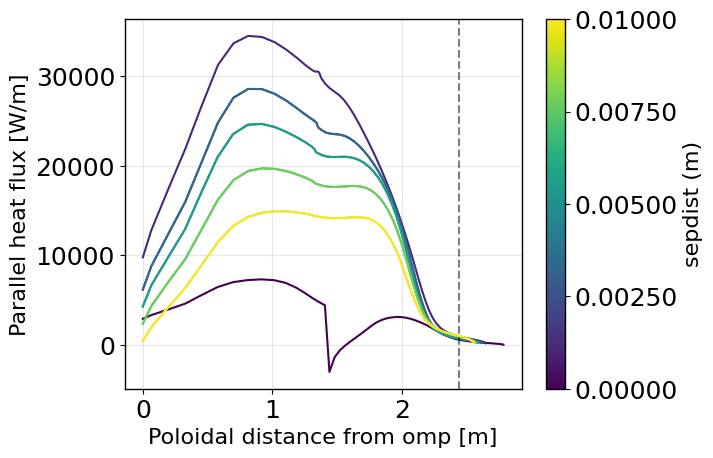

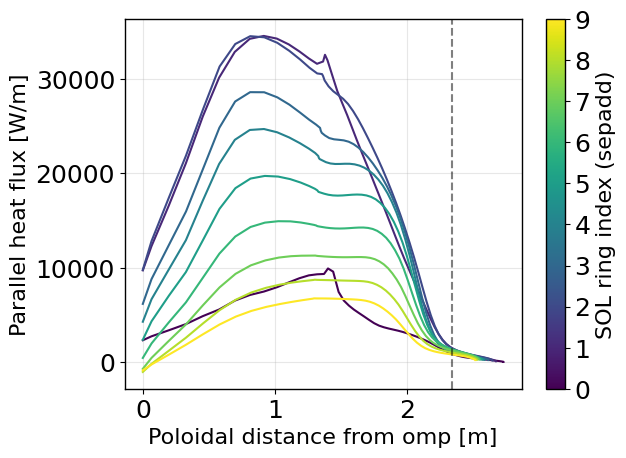

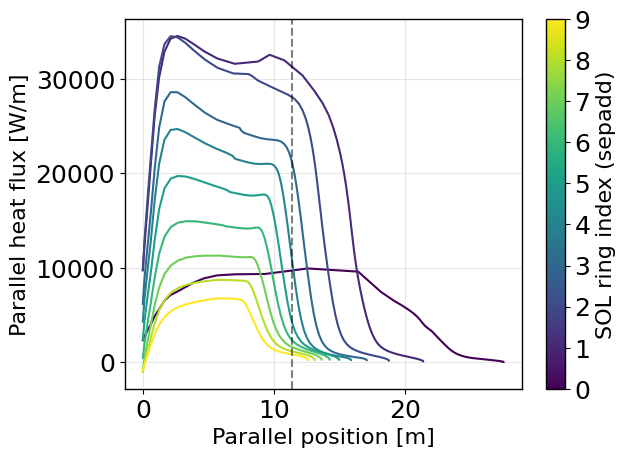

In [16]:
import matplotlib as mpl

def plot_fhex_total_colorcase(case, mode='sepdist', nlines=10, sepdist_range=(0,0.01), sepadd_range=(0,9), xkey="Spol"):
    """
    Plot fhex_total vs chosen x axis (Spar or Spol), colored by either sepadd (SOL ring index, integer) or sepdist (radial distance, float).

    Parameters:
        case: The simulation or equilibrium case object.
        mode: 'sepdist' (default) or 'sepadd'. Determines which variable will be mapped to color.
        nlines: Number of lines to plot.
        sepdist_range: (min,max) for sepdist spacing. Used if mode == 'sepdist'.
        sepadd_range: (min,max) for sepadd indices. Used if mode == 'sepadd'.
        xkey: "Spol" (default) or "Spar". Chooses which distance to plot on x axis.
    """
    fig, ax = plt.subplots()
    cmap = plt.get_cmap('viridis')

    if mode == 'sepadd':
        sepadds = np.arange(sepadd_range[0], sepadd_range[1]+1)
        norm = mpl.colors.Normalize(vmin=sepadds[0], vmax=sepadds[-1])
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

        for i in sepadds:
            fline = case.get_1d_poloidal_data(
                params = ["R", "Z", "Te", 'fhex_total', 'fhix_total', 'Bpol'],
                region = "outer_lower",
                sepadd = i,
                # sepdist = None,
                target_first = False,
                guards = False
            )
            color = cmap(norm(i))
            # safely get the x data
            xdata = fline[xkey] if xkey in fline else fline['Spol']
            ax.plot(xdata, fline['fhex_total'], color=color,
                    label=f"SOL ring {i}" if i==sepadds[0] else None)
        cbar = fig.colorbar(sm, ax=ax, ticks=sepadds)
        cbar.set_label('SOL ring index (sepadd)')
        cbar.set_ticks(sepadds)
        cbar.set_ticklabels([str(i) for i in sepadds])
        final_fline = fline

    elif mode == 'sepdist':
        sepdist_vals = np.linspace(sepdist_range[0], sepdist_range[1], nlines)
        norm = mpl.colors.Normalize(vmin=sepdist_vals[0], vmax=sepdist_vals[-1])
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

        for i in sepdist_vals:
            fline = case.get_1d_poloidal_data(
                params = ["R", "Z", "Te", 'fhex_total', 'fhix_total', 'Bpol'],
                region = "outer_lower",
                # sepadd = None, 
                sepdist = i,
                target_first = False,
                guards = False
            )
            color = cmap(norm(i))
            xdata = fline[xkey] if xkey in fline else fline['Spol']
            ax.plot(xdata, fline['fhex_total'], color=color)
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label('sepdist (m)')
        cbar.set_ticks(np.round(np.linspace(sepdist_vals[0], sepdist_vals[-1], 5), decimals=5))
        cbar.set_ticklabels([f"{v:.5f}" for v in np.linspace(sepdist_vals[0], sepdist_vals[-1], 5)])
        final_fline = fline

    else:
        raise ValueError("mode must be 'sepadd' or 'sepdist'")

    # Mark the X-point on the chosen axis
    xpt_indx = np.argmin(final_fline['Bpol'])
    xaxis_vals = final_fline[xkey] if xkey in final_fline else final_fline['Spol']
    ax.axvline(xaxis_vals[xpt_indx], color='k', linestyle='--', alpha=0.5, label='X-point')

    label_map = {
        "Spol": "Poloidal distance from omp [m]",
        "Spar": "Parallel position [m]"
    }
    ax.set_xlabel(label_map.get(xkey, xkey))
    ax.set_ylabel("Parallel heat flux [W/m]")
    # ax.set_title("Parallel heat flux at detachment front")
    ax.grid(True, alpha=0.3)
    plt.show()

# Example function calls:
plot_fhex_total_colorcase(case, mode='sepdist', nlines=10, sepdist_range=(0,0.01))
plot_fhex_total_colorcase(case, mode='sepadd', sepadd_range=(0,9), nlines=10)
# Example with Spar as x axis:
plot_fhex_total_colorcase(case, mode='sepadd', sepadd_range=(0,9), nlines=10, xkey="Spar")


# Source profiles


# Poloidal power distribution

In [ ]:
def get_power_src(case, sol_rings=6, sum_result=True, plot_result=False):
    """
    Collects fhex_total up to (but not including) the X-point for rings in the SOL,
    and separately for the 'far' (ring outside the SOL) up to the X-point.
    If sum_result=True, returns sums (as before).
    If sum_result=False, returns the arrays up to X-point for each ring.
    Returns dict with 'p_sol' and 'p_far'. 'p_sol' is either a 1D array of totals (if summed)
    or a list of arrays, one per SOL ring (if not summed).
    """

    # We don't know the final shape up front, so use lists to collect, then stack at end
    p_sol_list = []
    p_far_result = None

    for i in range(sol_rings):
        fline_sol = case.get_1d_poloidal_data(
            params=["R", "Z", "fhex_total", 'fhix_total', 'Bpol', 'Btot'],
            region="outer_lower",
            sepadd=i,
            target_first=False,
            guards=False
        )
        xpt_indx = np.argmin(fline_sol['Bpol'])
        # Collect fhex_total up to X-point for this ring
        p_sol_list.append(np.array(fline_sol['fhex_total'][:xpt_indx]))

    # If sum_result: sum each, so p_sol is a 1D array for each ring (total power for each)
    # Else: provide arrays up to x-point for each ring
    if sum_result:
        p_sol = np.array([arr.sum() for arr in p_sol_list])
    else:
        p_sol = p_sol_list  # List of 1D arrays (power profile per ring up to X-point)

    # Get power in the 'far' region after X-point outside the SOL
    fline_far = case.get_1d_poloidal_data(
        params=["R", "Z", "fhex_total", 'fhix_total', 'Bpol', 'Btot'],
        region="outer_lower",
        sepadd=sol_rings + 1,
        target_first=False,
        guards=False
    )
    xpt_indx = np.argmin(fline_far['Bpol'])
    if sum_result:
        p_far = np.array(fline_far['fhex_total'][:xpt_indx]).sum()
    else:
        p_far = np.array(fline_far['fhex_total'][:xpt_indx])

    power_src = {'p_sol': p_sol, 'p_far': p_far}

    if plot_result and not sum_result:
        fig, ax = plt.subplots()
        ax.plot(power_src['p_sol'], label='SOL rings')
        ax.plot(power_src['p_far'], label='Far field')
        ax.set_xlabel('Ring index')
        ax.set_ylabel('Power [W/m]')
        ax.legend()

    elif plot_result and sum_result:
        print('Can only plot non-summed profiles')

    return power_src

# Example usage:
# Get only sums (default)
test_sum = get_power_src(case, sol_rings=6, sum_result=True)
print("Summed result:", test_sum)

# Get arrays up to the x-point (profiles)
test_profiles = get_power_src(case, sol_rings=6, sum_result=False)
print("Profiles up to X-point:", test_profiles)


Summed result: {'p_sol': array([ 97026.83315018, 413926.09819378, 413781.27345575, 330798.35164613,
       282515.46326798, 642873.81669372]), 'p_far': np.float64(395203.49054968747)}
Profiles up to X-point: {'p_sol': [array([2310.58800258, 2728.53741403, 3366.17785827, 4021.77445407,
       4860.30520985, 5571.04965734, 6518.66203316, 7108.00376288,
       7472.99570899, 7930.24796426, 8438.81445892, 8879.65661684,
       9187.08382431, 9299.4128023 , 9333.52338238]), array([ 9713.71687092, 12280.14247921, 16581.79440808, 21069.3701293 ,
       26016.85802133, 30132.67656028, 32867.00703655, 34249.73948839,
       34558.24423504, 34275.00241097, 33659.82252196, 32906.15633976,
       32163.83349556, 31604.70831202, 31847.0258844 ]), array([ 9771.81788954, 12811.20305346, 17414.13757706, 21866.24772394,
       26806.73299971, 31318.08876249, 33699.27063684, 34530.71425987,
       34411.97134378, 33829.42360264, 32983.14940016, 32061.62700874,
       31179.26243641, 30582.9951908 , 3051

In [ ]:

# fline1 = case.get_1d_poloidal_data(
#     params = ["R", "Z", "fhey_total", 'fhiy_total', 'Bpol', 'Btot'],
#     region = "outer_lower",
#     sepadd = 0,
#     target_first = False,
#     guards = False
# )

# fline2 = case.get_1d_poloidal_data(
#     params = ["R", "Z", "fhey_total", 'fhiy_total', 'Bpol', 'Btot'],
#     region = "outer_lower",
#     sepadd = 1,
#     target_first = False,
#     guards = False
# )

# net_flux_e = fline1['fhey_total'] #- fline2['fhiy_total']
# net_flux_i = fline1['fhiy_total'] #- fline2['fhey_total']

# xpt_indx = np.argmin(fline1['Bpol'])

# # fline = fline.iloc[:xpt_indx]
# fig, ax = plt.subplots()
# ax.plot(fline['Spar'], net_flux_e, label='fhey_total', color = 'blue')
# ax.plot(fline['Spar'], net_flux_i, label='fhiy_total', color = 'red')
# ax.axvline(fline['Spar'][xpt_indx], color='k', linestyle='--', alpha=0.5, label='X-point')
# ax.set_xlabel("Parallel position [m]")
# ax.set_ylabel("Perpendicular heat flux [W/m]")
# ax.legend()
# ax.grid(True, alpha=0.3)


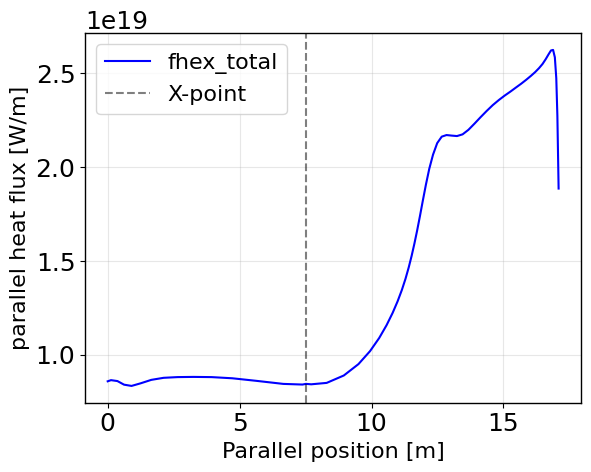

In [ ]:
fline1 = case.get_1d_poloidal_data(
    params = ["R", "Z", "fhex_total", 'fhix_total', 'Bpol', 'Btot', 'Ne'],
    region = "outer_lower",
    sepadd = 3,
    target_first = False,
    guards = False
)

xpt_indx = np.argmin(fline1['Bpol'])


fig,ax = plt.subplots()
ax.plot(fline1['Spar'], fline1['Ne'], label='fhex_total', color = 'blue')
# ax.plot(fline1['Spar'], fline1['fhix_total'], label='fhix_total', color = 'red')
ax.axvline(fline1['Spar'][xpt_indx], color='k', linestyle='--', alpha=0.5, label='X-point')
ax.set_xlabel("Parallel position [m]")
ax.set_ylabel("parallel heat flux [W/m]")
ax.legend()
# ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Poloidal particle source distribution

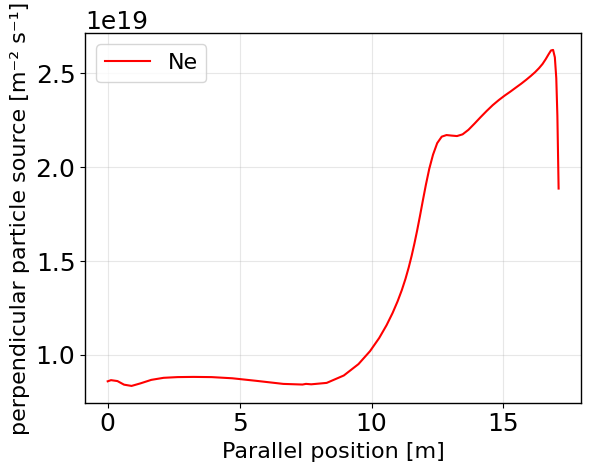

In [ ]:
fline1 = case.get_1d_poloidal_data(
    params = ["R", "Z", "fnay_D+1_tot", 'Bpol', 'Btot', 'Ne'],
    region = "outer_lower",
    sepadd = 3,
    target_first = False,
    guards = False
)

fline2 = case.get_1d_poloidal_data(
    params = ["R", "Z", "fnay_D+1_tot", 'Bpol', 'Btot', 'Ne'],
    region = "outer_lower",
    sepadd = 4,
    target_first = False,
    guards = False
)

net_flux = fline1['fnay_D+1_tot']

fig, ax = plt.subplots()
# ax.plot(fline1['Spar'], net_flux, label='fnay_D+1_tot', color = 'blue')
ax.plot(fline1['Spar'], fline1['Ne'], label='Ne', color = 'red')
# ax.plot(fline1['Spar'], net_flux_i, label='fnay_D+2_tot', color = 'red')
ax.set_xlabel("Parallel position [m]")
ax.set_ylabel("perpendicular particle source [m⁻² s⁻¹]")
ax.legend()
ax.grid(True, alpha=0.3)




#